In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from sklearn.datasets import fetch_olivetti_faces
import scipy.io
from PIL import Image
import random
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedShuffleSplit
import scanpy as sc
from pathlib import Path

# t-SNE spectral

In [35]:
def grid_search(diff_i: np.ndarray, i: int, perplexity: int) -> float:
    """
    Helper function to obtain σ's based on user-specified perplexity.

    Parameters:
        diff_i (np.ndarray): Array containing the pairwise differences between data points.
        i (int): Index of the current data point.
        perplexity (int): User-specified perplexity value.

    Returns:
        float: The value of σ that satisfies the perplexity condition.
    """

    result = np.inf  # Set first result to be infinity

    norm = np.linalg.norm(diff_i, axis=1)
    std_norm = np.std(norm)  # Use standard deviation of norms to define search space

    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        # Equation 1 Numerator
        p = np.exp(-(norm**2) / (2 * sigma_search**2))

        # Set p = 0 when i = j
        p[i] = 0

        # Equation 1 (ε -> 0)
        epsilon = np.nextafter(0, 1)
        p_new = np.maximum(p / (np.sum(p)+epsilon), epsilon)

        # Shannon Entropy
        H = -np.sum(p_new * np.log2(p_new))

        # Get log(perplexity equation) as close to equality
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search

    return sigma

def get_original_pairwise_affinities(X: np.ndarray, perplexity: int = 10) -> np.ndarray:
    """
    Function to obtain affinities matrix.

    Parameters:
    X (np.ndarray): The input data array.
    perplexity (int): The perplexity value for the grid search.

    Returns:
    np.ndarray: The pairwise affinities matrix.
    """

    n = len(X)

    print("Computing Pairwise Affinities....")

    p_ij = np.zeros(shape=(n, n))
    for i in range(0, n):
        # Equation 1 numerator
        diff = X[i] - X
        sigma_i = grid_search(diff, i, perplexity)  # Grid Search for σ_i
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = np.exp(-(norm**2) / (2 * sigma_i**2))

        # Set p = 0 when j = i
        np.fill_diagonal(p_ij, 0)

        # Equation 1
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])

    # Set 0 values to minimum numpy value (ε approx. = 0)
    epsilon = np.nextafter(0, 1)
    p_ij = np.maximum(p_ij, epsilon)

    print("Completed Pairwise Affinities Matrix. n")

    return p_ij


def get_symmetric_p_ij(p_ij: np.ndarray) -> np.ndarray:
    """
    Function to obtain symmetric affinities matrix utilized in t-SNE.

    Parameters:
    p_ij (np.ndarray): The input affinity matrix.

    Returns:
    np.ndarray: The symmetric affinities matrix.

    """
    print("Computing Symmetric p_ij matrix....")

    n = len(p_ij)
    p_ij_symmetric = np.zeros(shape=(n, n))
    for i in range(0, n):
        for j in range(0, n):
            p_ij_symmetric[i, j] = (p_ij[i, j] + p_ij[j, i]) / (2 * n)

    # Set 0 values to minimum numpy value (ε approx. = 0)
    epsilon = np.nextafter(0, 1)
    p_ij_symmetric = np.maximum(p_ij_symmetric, epsilon)

    print("Completed Symmetric p_ij Matrix. n")

    return p_ij_symmetric

def spectral_init(X: np.ndarray, n_dimensions: int = 2, k: int = 10) -> np.ndarray:
    """
    Spectral initialization for t-SNE using the first non-trivial eigenvectors
    of the unnormalized graph Laplacian.

    Parameters:
        X (np.ndarray): Input data (n_samples x n_features)
        n_dimensions (int): Target number of dimensions
        k (int): Number of nearest neighbors for graph construction

    Returns:
        np.ndarray: Initial embedding (n_samples x n_dimensions)
    """
    n = X.shape[0]

    p_ij = get_original_pairwise_affinities(X, 30)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    W = p_ij_symmetric.copy()
    np.fill_diagonal(W, 0)

    D = np.diag(W.sum(axis=1))
    L = D - W

    eigvals, eigvecs = np.linalg.eigh(L)
    return eigvecs[:, 1:n_dimensions + 1]

def laplacian_eigenmaps_init(X: np.ndarray, n_dimensions: int = 2, k: int = 10, sigma: float = None, normalized: bool = True) -> np.ndarray:
    """
    Laplacian Eigenmaps initialization for t-SNE Using Belkin and Niyogis definition.

    Parameters:
    X : np.ndarray, shape (n_samples, n_features)
        Input data.
    n_dimensions : int
        Number of target dimensions.
    k : int
        Number of nearest neighbors to use when constructing the graph.
    sigma : float or None
        Heat-kernel width. If None, set to the average distance to the k-th neighbor.
    normalized : bool
        If True, use symmetric normalized laplacian L = I - D^{-1/2} * W * D^{-1/2}
        If False, use unnormalized Laplacian L = D - W

    Returns:
    Y : np.ndarray, shape (n_samples, n_dimensions)
        The embedding given by the nontrivial eigenvectors of L  
    """
    n = X.shape[0]

    # --- Step 1: kNN graph (unchanged) ---
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    distances, indices = nbrs.kneighbors()
    distances, indices = distances[:, 1:], indices[:, 1:]

    # --- Step 2: Weights (FIX 1 & 2) ---
    rows = np.repeat(np.arange(n), k)
    cols = indices.ravel()

    if sigma is None:
        # Simple 0-1 weights (B&N Section 3.1)
        vals = np.ones(len(rows))
    else:
        # Heat kernel with fixed t, not data-adaptive sigma (FIX 1)
        vals = np.exp(-distances.ravel()**2 / sigma)

    W = csr_matrix((vals, (rows, cols)), shape=(n, n))
    W = W.maximum(W.T)   # Union of neighborhoods, not average (FIX 2)

    # --- Step 3: Laplacian (FIX 3) ---
    degrees = np.array(W.sum(axis=1)).ravel()

    if normalized:
        inv_sqrt_deg = np.zeros_like(degrees)
        nonzero = degrees > 0
        inv_sqrt_deg[nonzero] = 1.0 / np.sqrt(degrees[nonzero])
        D_inv_sqrt = csr_matrix(np.diag(inv_sqrt_deg))
        L = csr_matrix(np.eye(n)) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        # Unnormalized: L = D - W  ← true B&N default (FIX 3)
        D = csr_matrix(np.diag(degrees))
        L = D - W

    # --- Step 4: Eigenvectors (unchanged) ---
    vals, vecs = eigsh(L, k=n_dimensions+1, which='SM')

    return vecs[:, 1:n_dimensions+1]


def initialization(X: np.ndarray, n_dimensions: int = 2, initialization: str = "PCA", **kwargs) -> np.ndarray:
    if initialization == "random":
        return np.random.normal(loc=0, scale=1e-4, size=(len(X), n_dimensions))

    elif initialization == "PCA":
        X_centered = X - X.mean(axis=0)
        _, _, Vt = np.linalg.svd(X_centered)
        return X_centered @ Vt.T[:, :n_dimensions]

    elif initialization == "spectral":
        k = kwargs.get("k", 10)  # allow user to pass custom k
        return spectral_init(X, n_dimensions=n_dimensions, k=k)

    elif initialization == "laplacian":
        k = kwargs.get("k", 10)
        sigma = kwargs.get("sigma", None)
        return laplacian_eigenmaps_init(X, n_dimensions=n_dimensions, k=k, sigma=sigma)


    else:
        raise ValueError("Initialization must be 'random', 'PCA', 'spectral', or 'laplacian'")



def get_low_dimensional_affinities(Y: np.ndarray) -> np.ndarray:
    """
    Obtain low-dimensional affinities.

    Parameters:
    Y (np.ndarray): The low-dimensional representation of the data points.

    Returns:
    np.ndarray: The low-dimensional affinities matrix.
    """

    n = len(Y)
    q_ij = np.zeros(shape=(n, n))

    for i in range(0, n):
        # Equation 4 Numerator
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1)

    # Set p = 0 when j = i
    np.fill_diagonal(q_ij, 0)

    # Equation 4
    q_ij = q_ij / q_ij.sum()

    # Set 0 values to minimum numpy value (ε approx. = 0)
    ε = np.nextafter(0, 1)
    q_ij = np.maximum(q_ij, ε)

    return q_ij

def get_gradient(p_ij: np.ndarray, q_ij: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """
    Obtain gradient of cost function at current point Y.

    Parameters:
    p_ij (np.ndarray): The joint probability distribution matrix.
    q_ij (np.ndarray): The Student's t-distribution matrix.
    Y (np.ndarray): The current point in the low-dimensional space.

    Returns:
    np.ndarray: The gradient of the cost function at the current point Y.
    """

    n = len(p_ij)

    # Compute gradient
    gradient = np.zeros(shape=(n, Y.shape[1]))
    for i in range(0, n):
        # Equation 5
        diff = Y[i] - Y
        A = np.array([(p_ij[i, :] - q_ij[i, :])])
        B = np.array([(1 + (np.linalg.norm(diff, axis=1)) ** 2) ** (-1)])
        C = diff
        gradient[i] = 4 * np.sum((A * B).T * C, axis=0)
    
    return gradient

def tsne_eigen(
    X: np.ndarray,
    perplexity: int = 30,
    T: int = 1000,
    eta: int = 500,
    early_exaggeration: int = 12,
    initialization_method = 'PCA',
    n_dimensions: int = 2,
    **kwargs
) -> np.ndarray:
    """
    t-SNE (t-Distributed Stochastic Neighbor Embedding) algorithm implementation.

    Args:
        X (np.ndarray): The input data matrix of shape (n_samples, n_features).
        perplexity (int, optional): The perplexity parameter. Default is 10.
        T (int, optional): The number of iterations for optimization. Default is 1000.
        η (int, optional): The learning rate for updating the low-dimensional embeddings. Default is 200.
        early_exaggeration (int, optional): The factor by which the pairwise affinities are exaggerated
            during the early iterations of optimization. Default is 4.
        n_dimensions (int, optional): The number of dimensions of the low-dimensional embeddings. Default is 2.

    Returns:
        list[np.ndarray, np.ndarray]: A list containing the final low-dimensional embeddings and the history
            of embeddings at each iteration.

    """
    n = len(X)

    # Get original affinities matrix
    p_ij = get_original_pairwise_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    # Initialization
    Y = np.zeros(shape=(T, n, n_dimensions))
    Y_minus1 = np.zeros(shape=(n, n_dimensions))
    Y[0] = Y_minus1
    Y1 = initialization(X, n_dimensions=n_dimensions, initialization=initialization_method, **kwargs)
    Y[1] = np.array(Y1)

    print("Optimizing Low Dimensional Embedding....")
    # Optimization
    for t in range(1, T - 1):
        # Momentum &amp; Early Exaggeration
        if t < 250:
            alpha = 0
            early_exaggeration = early_exaggeration
        else:
            alpha = 0
            early_exaggeration = 1

        # Get Low Dimensional Affinities
        q_ij = get_low_dimensional_affinities(Y[t])

        # Get Gradient of Cost Function
        gradient = get_gradient(early_exaggeration * p_ij_symmetric, q_ij, Y[t])

        # Update Rule
        Y[t + 1] = Y[t] - eta * gradient + alpha * (Y[t] - Y[t - 1])  # Use negative gradient

        # Compute current value of cost function
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Value of Cost Function is {cost}")

    print(
        f"Completed Low Dimensional Embedding: Final Value of Cost Function is {np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))}"
    )
    solution = Y[-1]

    return solution

# Datasets

In [82]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Use full training set
x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype(np.float32)
x_test_flat  = x_test.reshape((x_test.shape[0], -1)).astype(np.float32)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled  = scaler.transform(x_test_flat)

pca = PCA(n_components=30)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca  = pca.transform(x_test_scaled)

In [83]:
# Load ALL images (no 500-cap)
files = sorted(
    [f for f in os.listdir(train_path) if f.endswith('.png')],
    key=lambda x: int(os.path.splitext(x)[0])
)
paths_all = [os.path.join(train_path, f) for f in files]

# Reset index in case labels_df was already indexed by 'id'
labels_df = pd.read_csv(labels_path)
labels_df['id'] = labels_df['id'].astype(int)
labels_df = labels_df.set_index('id')

y_all = np.array([labels_df.at[int(os.path.splitext(f)[0]), 'label'] for f in files])
le_all = LabelEncoder()
y_cifar = le_all.fit_transform(y_all.astype(str))

# Stratified 5000-image subset (500 per class)
rng2 = np.random.default_rng(42)
idx_5k = []
for c in range(len(le_all.classes_)):
    idx_c = np.where(y_cifar == c)[0]
    idx_5k.append(rng2.choice(idx_c, size=500, replace=False))
idx_5k = np.concatenate(idx_5k)
paths_all = [paths_all[i] for i in idx_5k]
y_cifar = y_cifar[idx_5k]

tfm = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class PathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths, self.transform = paths, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.transform(img) if self.transform else img

loader = DataLoader(PathsDataset(paths_all, tfm), batch_size=64, shuffle=False, num_workers=0)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval()
backbone = torch.nn.Sequential(*list(model.children())[:-1])

feats = []
with torch.no_grad():
    for xb in loader:
        z = backbone(xb).squeeze(-1).squeeze(-1)
        feats.append(z.cpu().numpy())
X_feat = np.concatenate(feats, axis=0)

X_30 = PCA(n_components=30, random_state=0).fit_transform(X_feat)
X_30 = normalize(X_30)
print(f'CIFAR10: {X_30.shape[0]} images loaded')

CIFAR10: 5000 images loaded


In [84]:
DATA_PATH = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"
df = pd.read_csv(DATA_PATH)

# Keep FULL dataset
y_cc = df['Class'].values
X_cc = df.drop(columns=['Class']).values

X_cc = StandardScaler().fit_transform(X_cc)
X_pca_cc = PCA(n_components=30, random_state=0).fit_transform(X_cc)
print(f'CreditCard: {X_pca_cc.shape[0]} rows loaded')

CreditCard: 284807 rows loaded


In [85]:
adata = sc.datasets.pbmc3k()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, subset=True)
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, n_comps=30, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata, resolution=0.6)

# Keep FULL dataset — no subsample
X_pca_rna = adata.obsm['X_pca']
labels_rna = adata.obs['leiden'].to_numpy()
print(f'PBMC_RNA: {X_pca_rna.shape[0]} cells loaded')

PBMC_RNA: 2700 cells loaded


In [86]:
# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=1)
X = faces.data
y_f = faces.target

# Take first 1500 samples for simplicity
X = X[:1500]
y_f = y_f[:1500]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 30 components
pca = PCA(n_components=30)
X_pca_face = pca.fit_transform(X_scaled)

In [87]:
path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X = []
y_c = []

for file in sorted(os.listdir(path)):
    if file.endswith(".png"):
        label = int(file.split("_")[0].replace("obj", ""))
        img = Image.open(os.path.join(path, file)).convert("L").resize((32, 32))  # resize if needed
        X.append(np.array(img).flatten())
        y_c.append(label)

X = np.array(X)
y_c = np.array(y_c)

# Scale and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=30)
X_pca_coil = pca.fit_transform(X_scaled)

# Comparison function

In [88]:
"""
t-SNE Initialization Benchmarking Pipeline
Compares: PCA, Spectral, Laplacian initializations
Across: 6 datasets, 12 random samples, with/without gradient descent
Outputs: Figures (line, boxplots, bar charts) + Excel summary
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import (
    load_iris, load_digits, load_wine, load_breast_cancer,
    fetch_openml, make_swiss_roll
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── paste your implementations here ──────────────────────────────────────────

def grid_search(diff_i, i, perplexity):
    result = np.inf
    norm = np.linalg.norm(diff_i, axis=1)
    std_norm = np.std(norm)
    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        p = np.exp(-(norm**2) / (2 * sigma_search**2))
        p[i] = 0
        epsilon = np.nextafter(0, 1)
        p_new = np.maximum(p / (np.sum(p) + epsilon), epsilon)
        H = -np.sum(p_new * np.log2(p_new))
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search
    return sigma


def get_original_pairwise_affinities(X, perplexity=10):
    n = len(X)
    p_ij = np.zeros((n, n))
    for i in range(n):
        diff = X[i] - X
        sigma_i = grid_search(diff, i, perplexity)
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = np.exp(-(norm**2) / (2 * sigma_i**2))
        np.fill_diagonal(p_ij, 0)
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])
    epsilon = np.nextafter(0, 1)
    p_ij = np.maximum(p_ij, epsilon)
    return p_ij


def get_symmetric_p_ij(p_ij):
    n = len(p_ij)
    p_ij_sym = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            p_ij_sym[i, j] = (p_ij[i, j] + p_ij[j, i]) / (2 * n)
    epsilon = np.nextafter(0, 1)
    return np.maximum(p_ij_sym, epsilon)


def spectral_init(X, n_dimensions=2, **kwargs):
    P = tsne_joint_probabilities(X, perplexity=30.0)
    np.fill_diagonal(P, 0)
    D = np.diag(P.sum(axis=1))
    L = D - P
    _, eigvecs = np.linalg.eigh(L)
    return eigvecs[:, 1:n_dimensions + 1]


def laplacian_eigenmaps_init(X, n_dimensions=2, k=10, t=None, normalized=False, **kwargs):
    n = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(X)
    distances, indices = nbrs.kneighbors()
    distances, indices = distances[:, 1:], indices[:, 1:]
    rows = np.repeat(np.arange(n), k)
    cols = indices.ravel()
    if t is None:
        vals = np.ones(len(rows))
    else:
        vals = np.exp(-distances.ravel()**2 / t)
    W = csr_matrix((vals, (rows, cols)), shape=(n, n))
    W = W.maximum(W.T)
    degrees = np.array(W.sum(axis=1)).ravel()
    if normalized:
        inv_sqrt = np.zeros_like(degrees)
        nz = degrees > 0
        inv_sqrt[nz] = 1.0 / np.sqrt(degrees[nz])
        D_inv_sqrt = csr_matrix(np.diag(inv_sqrt))
        L = csr_matrix(np.eye(n)) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        L = csr_matrix(np.diag(degrees)) - W
    vals_eig, vecs = eigsh(L, k=n_dimensions + 1, which='SM')
    return vecs[:, 1:n_dimensions + 1]


def pca_init(X, n_dimensions=2, **kwargs):
    X_c = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_c)
    return X_c @ Vt.T[:, :n_dimensions]


def get_low_dimensional_affinities(Y):
    n = len(Y)
    q_ij = np.zeros((n, n))
    for i in range(n):
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1)
    np.fill_diagonal(q_ij, 0)
    q_ij = q_ij / q_ij.sum()
    epsilon = np.nextafter(0, 1)
    return np.maximum(q_ij, epsilon)


def get_gradient(p_ij, q_ij, Y):
    n = len(p_ij)
    gradient = np.zeros((n, Y.shape[1]))
    for i in range(n):
        diff = Y[i] - Y
        A = np.array([(p_ij[i, :] - q_ij[i, :])])
        B = np.array([(1 + np.linalg.norm(diff, axis=1)**2) ** (-1)])
        gradient[i] = 4 * np.sum((A * B).T * diff, axis=0)
    return gradient


def kl_divergence(p, q):
    return float(np.sum(p * np.log(p / q)))


def run_tsne(X, p_ij_sym, Y_init, T=300, eta=500, early_exaggeration=12, return_Y=False):
    n = len(X)
    Y = np.zeros((T, n, 2))
    Y[0] = np.zeros((n, 2))
    Y[1] = Y_init.copy()
    for t in range(1, T - 1):
        ee = early_exaggeration if t < 250 else 1
        q_ij = get_low_dimensional_affinities(Y[t])
        grad = get_gradient(ee * p_ij_sym, q_ij, Y[t])
        Y[t + 1] = Y[t] - eta * grad
    q_final = get_low_dimensional_affinities(Y[-1])
    kl = kl_divergence(p_ij_sym, q_final)
    if return_Y:
        return kl, Y[-1]
    return kl


# ── Benchmarking ──────────────────────────────────────────────────────────────

METHODS = {
    "PCA":       pca_init,
    "Spectral":  spectral_init,
    "Laplacian": laplacian_eigenmaps_init,
}

COLORS = {
    "PCA":       "#4C72B0",
    "Spectral":  "#DD8452",
    "Laplacian": "#55A868",
}


def benchmark_dataset(X, y, dataset_name, n_samples=12, sample_size=500, run_gd=True, T=300, run_seed=42):
    print(f"\n  === {dataset_name} ===")

    results = {m: {"init_kl": [], "gd_kl": [], "init_time": [], "gd_time": []} for m in METHODS}
    rng = np.random.RandomState(run_seed)

    for sample_idx in range(n_samples):
        print(f"    Sample {sample_idx+1}/{n_samples}", flush=True)

        n = len(X)
        if sample_size is None or sample_size >= n:
            idx = rng.choice(n, size=min(500, n), replace=False)
        elif y is not None and len(np.unique(y)) > 1:
            sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=sample_idx)
            idx, _ = next(sss.split(X, y))
        else:
            idx = rng.choice(n, size=sample_size, replace=False)

        X_s = X[idx]

        # --- compute fresh P for this subsample ---
        print("    Computing affinities...", flush=True)
        p_ij = get_original_pairwise_affinities(X_s, perplexity=30)
        p_s = get_symmetric_p_ij(p_ij)

        for method_name, init_fn in METHODS.items():
            t0 = time.time()
            Y_init = init_fn(X_s, n_dimensions=2)
            init_kl, _ = run_tsne(X_s, p_s, Y_init, T=3, return_Y=True)
            init_time = time.time() - t0

            print(f"      {method_name} init_kl = {init_kl}", flush=True)  # ← add this

            results[method_name]["init_kl"].append(init_kl)
            results[method_name]["init_time"].append(init_time)

            if run_gd:
                t0 = time.time()
                Y_init_fresh = init_fn(X_s, n_dimensions=2)
                gd_kl = run_tsne(X_s, p_s, Y_init_fresh, T=T)
                gd_time = time.time() - t0

                print(f"      {method_name} gd_kl = {gd_kl}", flush=True)  # ← add this

                results[method_name]["gd_kl"].append(gd_kl)
                results[method_name]["gd_time"].append(gd_time)

    return results


# ── Plotting ──────────────────────────────────────────────────────────────────

def plot_dataset_figures(dataset_name, results, out_dir, mode="init"):
    """
    mode: "init" (no GD) or "gd" (with GD)
    Produces: line chart, KL boxplot, difference boxplot, runtime bar chart
    """
    key_kl   = "init_kl"   if mode == "init" else "gd_kl"
    key_time = "init_time" if mode == "init" else "gd_time"
    suffix   = "NoGD"      if mode == "init" else "WithGD"
    title_suffix = "No Gradient Descent" if mode == "init" else "With Gradient Descent"

    method_names = list(METHODS.keys())
    kl_data   = [results[m][key_kl]   for m in method_names]
    time_data  = [results[m][key_time] for m in method_names]
    n_samples  = len(kl_data[0])

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f"{dataset_name} — {title_suffix}", fontsize=16, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # ── 1. Line chart ────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])   # spans full top row
    for m, vals in zip(method_names, kl_data):
        ax1.plot(range(1, n_samples + 1), vals,
                 marker='o', label=m, color=COLORS[m], linewidth=2, markersize=6)
    ax1.set_title("KL Divergence per Sample Run", fontsize=13)
    ax1.set_xlabel("Sample Index")
    ax1.set_ylabel("KL Divergence")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── 2. KL Boxplot ────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    bp = ax2.boxplot(kl_data, patch_artist=True, labels=method_names)
    for patch, m in zip(bp['boxes'], method_names):
        patch.set_facecolor(COLORS[m])
        patch.set_alpha(0.7)
    ax2.set_title("Distribution of KL Divergence", fontsize=13)
    ax2.set_ylabel("KL Divergence")
    ax2.grid(True, alpha=0.3, axis='y')

    # ── 3. Pairwise difference boxplot ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    pairs = [("PCA", "Spectral"), ("PCA", "Laplacian"), ("Spectral", "Laplacian")]
    diff_data  = []
    diff_labels = []
    diff_colors = []
    pair_colors = ["#9B59B6", "#E74C3C", "#1ABC9C"]
    for (m1, m2), c in zip(pairs, pair_colors):
        d1 = np.array(results[m1][key_kl])
        d2 = np.array(results[m2][key_kl])
        diff_data.append(d1 - d2)
        diff_labels.append(f"{m1}\n− {m2}")
        diff_colors.append(c)
    bp2 = ax3.boxplot(diff_data, patch_artist=True, labels=diff_labels)
    for patch, c in zip(bp2['boxes'], diff_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax3.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax3.set_title("Pairwise KL Difference\n(positive = row method worse)", fontsize=13)
    ax3.set_ylabel("KL Difference")
    ax3.grid(True, alpha=0.3, axis='y')

    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_main.png"),
                dpi=150, bbox_inches='tight')
    plt.close()

    # ── 4. Runtime bar chart (separate figure) ───────────────────────────────
    fig2, ax = plt.subplots(figsize=(8, 5))
    means = [np.mean(t) for t in time_data]
    stds  = [np.std(t)  for t in time_data]
    bars  = ax.bar(method_names, means, yerr=stds, capsize=6,
                   color=[COLORS[m] for m in method_names], alpha=0.8, edgecolor='black')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) * 0.05,
                f"{mean:.2f}s", ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{dataset_name} — Average Runtime ({title_suffix})", fontsize=13)
    ax.set_ylabel("Time (seconds)")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_runtime.png"),
                dpi=150, bbox_inches='tight')
    plt.close()


# ── Excel export ──────────────────────────────────────────────────────────────

HDR_FILL  = PatternFill("solid", start_color="2F4F8F", end_color="2F4F8F")
HDR_FONT  = Font(bold=True, color="FFFFFF", name="Arial", size=10)
SUB_FILL  = PatternFill("solid", start_color="D9E1F2", end_color="D9E1F2")
SUB_FONT  = Font(bold=True, name="Arial", size=10)
DATA_FONT = Font(name="Arial", size=10)
CENTER    = Alignment(horizontal="center", vertical="center")
THIN      = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin')
)

METHOD_FILL = {
    "PCA":       PatternFill("solid", start_color="DAE8FC", end_color="DAE8FC"),
    "Spectral":  PatternFill("solid", start_color="FFE6CC", end_color="FFE6CC"),
    "Laplacian": PatternFill("solid", start_color="D5E8D4", end_color="D5E8D4"),
}


def _hdr(ws, cell, value, width=None):
    ws[cell] = value
    ws[cell].font = HDR_FONT
    ws[cell].fill = HDR_FILL
    ws[cell].alignment = CENTER
    ws[cell].border = THIN
    if width:
        col = cell[0] if len(cell) == 2 else cell[:2]
        ws.column_dimensions[col].width = width


def write_summary_sheet(ws, all_results, datasets, mode):
    """One sheet: rows = datasets × methods, cols = stats."""
    key_kl   = "init_kl"   if mode == "init" else "gd_kl"
    key_time = "init_time" if mode == "init" else "gd_time"

    headers = ["Dataset", "Method", "Mean KL", "Std KL", "Min KL", "Max KL",
               "Mean Time (s)", "Std Time (s)"]
    col_widths = [18, 14, 12, 12, 12, 12, 16, 16]

    for col_idx, (h, w) in enumerate(zip(headers, col_widths), 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font = HDR_FONT
        cell.fill = HDR_FILL
        cell.alignment = CENTER
        cell.border = THIN
        ws.column_dimensions[get_column_letter(col_idx)].width = w

    row = 2
    for ds_name in datasets:
        results = all_results[ds_name]
        for m in METHODS:
            kl_vals   = results[m][key_kl]
            time_vals = results[m][key_time]
            data_row  = [
                ds_name, m,
                f"=AVERAGE({get_column_letter(3)}{row}:{get_column_letter(3)}{row})",  # placeholder
                "", "", "", "", ""
            ]
            # Write raw values (let Excel compute nothing — we write computed python values directly)
            vals = [
                ds_name, m,
                round(np.mean(kl_vals),   4),
                round(np.std(kl_vals),    4),
                round(np.min(kl_vals),    4),
                round(np.max(kl_vals),    4),
                round(np.mean(time_vals), 4),
                round(np.std(time_vals),  4),
            ]
            fill = METHOD_FILL[m]
            for col_idx, v in enumerate(vals, 1):
                cell = ws.cell(row=row, column=col_idx, value=v)
                cell.font = DATA_FONT
                cell.fill = fill
                cell.alignment = CENTER
                cell.border = THIN
            row += 1

    ws.freeze_panes = "A2"


def write_raw_sheet(ws, all_results, datasets, mode):
    """One sheet with all raw per-sample KL values."""
    key = "init_kl" if mode == "init" else "gd_kl"
    n_samples = 12

    # Header: Dataset | Method | Sample1 ... Sample12
    headers = ["Dataset", "Method"] + [f"Sample {i+1}" for i in range(n_samples)]
    col_widths = [18, 14] + [10]*n_samples
    for col_idx, (h, w) in enumerate(zip(headers, col_widths), 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font = HDR_FONT
        cell.fill = HDR_FILL
        cell.alignment = CENTER
        cell.border = THIN
        ws.column_dimensions[get_column_letter(col_idx)].width = w

    row = 2
    for ds_name in datasets:
        results = all_results[ds_name]
        for m in METHODS:
            kl_vals = results[m][key]
            row_vals = [ds_name, m] + [round(v, 4) for v in kl_vals]
            fill = METHOD_FILL[m]
            for col_idx, v in enumerate(row_vals, 1):
                cell = ws.cell(row=row, column=col_idx, value=v)
                cell.font = DATA_FONT
                cell.fill = fill
                cell.alignment = CENTER
                cell.border = THIN
            row += 1

    ws.freeze_panes = "A2"


def write_comparison_sheet(ws, all_results, datasets, mode):
    """Side-by-side comparison: for each dataset, all 3 methods in columns."""
    key = "init_kl" if mode == "init" else "gd_kl"

    # Layout: rows = datasets, columns = method stats (mean/std/min/max)
    col_groups = list(METHODS.keys())
    sub_cols   = ["Mean KL", "Std KL", "Min KL", "Max KL"]

    ws.cell(row=1, column=1, value="Dataset").font = HDR_FONT
    ws.cell(row=1, column=1).fill = HDR_FILL
    ws.cell(row=1, column=1).alignment = CENTER
    ws.cell(row=1, column=1).border = THIN
    ws.column_dimensions["A"].width = 18

    col = 2
    for m in col_groups:
        ws.merge_cells(start_row=1, start_column=col, end_row=1, end_column=col+3)
        cell = ws.cell(row=1, column=col, value=m)
        cell.font = HDR_FONT
        cell.fill = METHOD_FILL[m]
        cell.font = Font(bold=True, name="Arial", size=10)
        cell.alignment = CENTER
        cell.border = THIN
        for i, sc in enumerate(sub_cols):
            c = ws.cell(row=2, column=col+i, value=sc)
            c.font = SUB_FONT
            c.fill = SUB_FILL
            c.alignment = CENTER
            c.border = THIN
            ws.column_dimensions[get_column_letter(col+i)].width = 12
        col += 4

    for row_idx, ds_name in enumerate(datasets, 3):
        ws.cell(row=row_idx, column=1, value=ds_name).font = DATA_FONT
        ws.cell(row=row_idx, column=1).alignment = CENTER
        ws.cell(row=row_idx, column=1).border = THIN
        col = 2
        for m in col_groups:
            kl = all_results[ds_name][m][key]
            stats = [np.mean(kl), np.std(kl), np.min(kl), np.max(kl)]
            for i, v in enumerate(stats):
                c = ws.cell(row=row_idx, column=col+i, value=round(v, 4))
                c.font = DATA_FONT
                c.alignment = CENTER
                c.border = THIN
            col += 4

    ws.freeze_panes = "B3"


def export_excel(all_results, datasets, out_path):
    wb = Workbook()

    # Remove default sheet
    wb.remove(wb.active)

    for mode, label in [("init", "NoGD"), ("gd", "WithGD")]:
        ws_sum  = wb.create_sheet(f"Summary_{label}")
        ws_raw  = wb.create_sheet(f"RawValues_{label}")
        ws_comp = wb.create_sheet(f"Comparison_{label}")

        write_summary_sheet(ws_sum,  all_results, datasets, mode)
        write_raw_sheet(ws_raw,      all_results, datasets, mode)
        write_comparison_sheet(ws_comp, all_results, datasets, mode)

    wb.save(out_path)
    print(f"\nExcel saved → {out_path}")


# ── Main ──────────────────────────────────────────────────────────────────────

def main(datasets: dict):
    """
    datasets: dict of {name: (X, y)} where X is np.ndarray (n_samples, n_features)
    Example:
        datasets = {
            "Iris": (X_iris, y_iris),
            "MNIST": (X_mnist, y_mnist),
        }
    """
    OUT_DIR = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Results"
    os.makedirs(OUT_DIR, exist_ok=True)

    N_SAMPLES = 12
    T_GD      = 1000

    sample_sizes = {
        "MNIST":         500,
        "CIFAR10":       500,
        "CreditCard":    500,
        "PBMC_RNA":      500,
        "OlivettiFaces": 150,
        "COIL20":        500,
    }

    dataset_names = list(datasets.keys())
    all_results   = {}

    for ds_name, (X, y) in datasets.items():
        ss = sample_sizes.get(ds_name, 500)
        print(f"\nBenchmarking: {ds_name}  (n={len(X)}, d={X.shape[1]})")
        res = benchmark_dataset(X, y, ds_name, n_samples=N_SAMPLES, sample_size=ss, run_gd=True, T=T_GD)
        all_results[ds_name] = res

        for mode in ["init", "gd"]:
            plot_dataset_figures(ds_name, res, OUT_DIR, mode=mode)

        print(f"  Figures saved for {ds_name}")

    excel_path = os.path.join(OUT_DIR, "tsne_benchmark_results.xlsx")
    export_excel(all_results, dataset_names, excel_path)

    print("\n✓ All done. Results in:", OUT_DIR)
    return all_results, dataset_names


## Comparisons

In [89]:
# MNIST — use full training set so subsampling has room to vary across 12 runs
(x_train_full, y_train_full), _ = mnist.load_data()
X_mnist_raw = x_train_full.reshape(x_train_full.shape[0], -1).astype(np.float32)
X_mnist_proc = PCA(n_components=30, random_state=0).fit_transform(
    StandardScaler().fit_transform(X_mnist_raw)
)

In [76]:
res = benchmark_dataset(X_pca_face, y_f, "OlivettiFaces", 
                        n_samples=12, sample_size=200, run_gd=True, T=1000)
all_results["OlivettiFaces"] = res
dataset_names = list(all_results.keys())

for mode in ["init", "gd"]:
    plot_dataset_figures("OlivettiFaces", res, OUT_DIR, mode=mode)

export_excel(all_results, dataset_names, excel_path)


  === OlivettiFaces ===
    Sample 1/12


    Computing affinities...
      PCA init_kl = 1.4263021436248646
      PCA gd_kl = 0.5114383217671208
      Spectral init_kl = 1.8851944354851813
      Spectral gd_kl = 0.5046421192080275
      Laplacian init_kl = 1.8541361826610536
      Laplacian gd_kl = 0.5375007435629058
    Sample 2/12
    Computing affinities...
      PCA init_kl = 1.448165446971042
      PCA gd_kl = 0.7751278268577111
      Spectral init_kl = 1.969943154615235
      Spectral gd_kl = 0.515995728200773
      Laplacian init_kl = 1.853506177925995
      Laplacian gd_kl = 0.5950293397447062
    Sample 3/12
    Computing affinities...
      PCA init_kl = 1.4651495053655748
      PCA gd_kl = 0.45373017560549267
      Spectral init_kl = 1.8294190994407664
      Spectral gd_kl = 0.6009835553480722
      Laplacian init_kl = 1.8939251072066332
      Laplacian gd_kl = 0.5811114153496257
    Sample 4/12
    Computing affinities...
      PCA init_kl = 1.4980274034782775
      PCA gd_kl = 0.5961962464134305
      Spectral in

In [58]:
def plot_dataset_figures(dataset_name, results, out_dir, mode="init"):
    """
    mode: "init" (no GD) or "gd" (with GD)
    Produces 4 individual figures, each saved as its own file:
      1. Line chart  — KL per sample run
      2. KL boxplot  — distribution of KL divergence
      3. Diff boxplot — pairwise KL differences
      4. Runtime bar chart
    """
    key_kl   = "init_kl"   if mode == "init" else "gd_kl"
    key_time = "init_time" if mode == "init" else "gd_time"
    suffix   = "NoGD"      if mode == "init" else "WithGD"
    title_suffix = "No Gradient Descent" if mode == "init" else "With Gradient Descent"

    method_names = list(METHODS.keys())
    kl_data   = [results[m][key_kl]   for m in method_names]
    time_data  = [results[m][key_time] for m in method_names]
    n_samples  = len(kl_data[0])

    # ── 1. Line chart ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, vals in zip(method_names, kl_data):
        ax.plot(range(1, n_samples + 1), vals,
                marker='o', label=m, color=COLORS[m], linewidth=2, markersize=6)
    ax.set_title(f"{dataset_name} — KL Divergence per Sample Run ({title_suffix})", fontsize=13)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("KL Divergence")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_line.png"),
                dpi=150, bbox_inches='tight')
    plt.close()

    # ── 2. KL Boxplot ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(kl_data, patch_artist=True, labels=method_names)
    for patch, m in zip(bp['boxes'], method_names):
        patch.set_facecolor(COLORS[m])
        patch.set_alpha(0.7)
    ax.set_title(f"{dataset_name} — Distribution of KL Divergence ({title_suffix})", fontsize=13)
    ax.set_ylabel("KL Divergence")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_kl_boxplot.png"),
                dpi=150, bbox_inches='tight')
    plt.close()

    # ── 3. Pairwise difference boxplot ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    pairs = [("PCA", "Spectral"), ("PCA", "Laplacian"), ("Spectral", "Laplacian")]
    diff_data   = []
    diff_labels = []
    diff_colors = []
    pair_colors = ["#9B59B6", "#E74C3C", "#1ABC9C"]
    for (m1, m2), c in zip(pairs, pair_colors):
        d1 = np.array(results[m1][key_kl])
        d2 = np.array(results[m2][key_kl])
        diff_data.append(d1 - d2)
        diff_labels.append(f"{m1}\n− {m2}")
        diff_colors.append(c)
    bp2 = ax.boxplot(diff_data, patch_artist=True, labels=diff_labels)
    for patch, c in zip(bp2['boxes'], diff_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f"{dataset_name} — Pairwise KL Difference ({title_suffix})\n(positive = first method worse)", fontsize=12)
    ax.set_ylabel("KL Difference")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_diff_boxplot.png"),
                dpi=150, bbox_inches='tight')
    plt.close()

    # ── 4. Runtime bar chart ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    means = [np.mean(t) for t in time_data]
    stds  = [np.std(t)  for t in time_data]
    bars  = ax.bar(method_names, means, yerr=stds, capsize=6,
                   color=[COLORS[m] for m in method_names], alpha=0.8, edgecolor='black')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) * 0.05,
                f"{mean:.2f}s", ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{dataset_name} — Average Runtime ({title_suffix})", fontsize=13)
    ax.set_ylabel("Time (seconds)")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_runtime.png"),
                dpi=150, bbox_inches='tight')
    plt.close()


In [59]:
OUT_DIR = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Results"

for ds_name, res in all_results.items():
    for mode in ["init", "gd"]:
        plot_dataset_figures(ds_name, res, OUT_DIR, mode=mode)
    print(f"Figures saved for {ds_name}")

Figures saved for OlivettiFaces


In [78]:
datasets = {
    "CIFAR10":       (X_30,          y_cifar),
    "OlivettiFaces": (X_pca_face,    y_f)
}

all_results, dataset_names = main(datasets)


Benchmarking: CIFAR10  (n=5000, d=30)

  === CIFAR10 ===
    Sample 1/12
    Computing affinities...
      PCA init_kl = 3.3973103354063516
      PCA gd_kl = 0.9404853265250366
      Spectral init_kl = 2.6697819183498406
      Spectral gd_kl = 1.0609199169037353
      Laplacian init_kl = 2.694038838790672
      Laplacian gd_kl = 0.9551891233842605
    Sample 2/12
    Computing affinities...
      PCA init_kl = 3.358262958173457
      PCA gd_kl = 0.9830513479662242
      Spectral init_kl = 2.661527546013
      Spectral gd_kl = 0.9998682514572823
      Laplacian init_kl = 2.6847800101402735
      Laplacian gd_kl = 1.0687629797920042
    Sample 3/12
    Computing affinities...
      PCA init_kl = 3.371694369347831
      PCA gd_kl = 1.007490251915827
      Spectral init_kl = 2.673612614913282
      Spectral gd_kl = 1.0361011409240495
      Laplacian init_kl = 2.6936698111260275
      Laplacian gd_kl = 1.0084094154545795
    Sample 4/12
    Computing affinities...
      PCA init_kl = 3.406

In [90]:
datasets = {
    "MNIST":         (X_mnist_proc,  y_train_full),
    "CIFAR10":       (X_30,          y_cifar),
    "CreditCard":    (X_pca_cc,      y_cc),
    "PBMC_RNA":      (X_pca_rna,     labels_rna),
    "OlivettiFaces": (X_pca_face,    y_f),
    "COIL20":        (X_pca_coil,    y_c),
}

all_results, dataset_names = main(datasets)

OUT_DIR = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Results"


Benchmarking: MNIST  (n=60000, d=30)

  === MNIST ===
    Sample 1/12
    Computing affinities...
      PCA init_kl = 2.8902256745733164
      PCA gd_kl = 1.146762234190186
      Spectral init_kl = 2.614847641195838
      Spectral gd_kl = 0.9756988182516948
      Laplacian init_kl = 2.614072911728726
      Laplacian gd_kl = 1.1955102371577633
    Sample 2/12
    Computing affinities...
      PCA init_kl = 2.934446232181336
      PCA gd_kl = 1.0911774191127208
      Spectral init_kl = 2.611773566750177
      Spectral gd_kl = 1.198381407053324
      Laplacian init_kl = 2.5981560633354017
      Laplacian gd_kl = 0.9647167420112231
    Sample 3/12
    Computing affinities...
      PCA init_kl = 2.92783925758183
      PCA gd_kl = 1.0254082764991646
      Spectral init_kl = 2.6354719332605376
      Spectral gd_kl = 0.9440532469678834
      Laplacian init_kl = 2.6327866368175776
      Laplacian gd_kl = 1.13552911093932
    Sample 4/12
    Computing affinities...
      PCA init_kl = 2.9581846

In [91]:
def plot_dataset_figures(dataset_name, results, out_dir, mode="init"):
    key_kl   = "init_kl"   if mode == "init" else "gd_kl"
    key_time = "init_time" if mode == "init" else "gd_time"
    suffix   = "NoGD"      if mode == "init" else "WithGD"
    title_suffix = "No Gradient Descent" if mode == "init" else "With Gradient Descent"

    method_names = list(METHODS.keys())
    kl_data   = [results[m][key_kl]   for m in method_names]
    time_data  = [results[m][key_time] for m in method_names]
    n_samples  = len(kl_data[0])

    # ── 1. Line chart
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, vals in zip(method_names, kl_data):
        ax.plot(range(1, n_samples + 1), vals,
                marker='o', label=m, color=COLORS[m], linewidth=2, markersize=6)
    ax.set_title(f"{dataset_name} — KL Divergence per Sample Run ({title_suffix})", fontsize=13)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("KL Divergence")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_line.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── 2. KL Boxplot
    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(kl_data, patch_artist=True, labels=method_names)
    for patch, m in zip(bp['boxes'], method_names):
        patch.set_facecolor(COLORS[m])
        patch.set_alpha(0.7)
    ax.set_title(f"{dataset_name} — Distribution of KL Divergence ({title_suffix})", fontsize=13)
    ax.set_ylabel("KL Divergence")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_kl_boxplot.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── 3. Pairwise difference boxplot
    fig, ax = plt.subplots(figsize=(7, 5))
    pairs = [("PCA", "Spectral"), ("PCA", "Laplacian"), ("Spectral", "Laplacian")]
    diff_data, diff_labels, diff_colors = [], [], []
    pair_colors = ["#9B59B6", "#E74C3C", "#1ABC9C"]
    for (m1, m2), c in zip(pairs, pair_colors):
        diff_data.append(np.array(results[m1][key_kl]) - np.array(results[m2][key_kl]))
        diff_labels.append(f"{m1}\n− {m2}")
        diff_colors.append(c)
    bp2 = ax.boxplot(diff_data, patch_artist=True, labels=diff_labels)
    for patch, c in zip(bp2['boxes'], diff_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f"{dataset_name} — Pairwise KL Difference ({title_suffix})\n(positive = first method worse)", fontsize=12)
    ax.set_ylabel("KL Difference")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_diff_boxplot.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── 4. Runtime bar chart
    fig, ax = plt.subplots(figsize=(7, 5))
    means = [np.mean(t) for t in time_data]
    stds  = [np.std(t)  for t in time_data]
    bars  = ax.bar(method_names, means, yerr=stds, capsize=6,
                   color=[COLORS[m] for m in method_names], alpha=0.8, edgecolor='black')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) * 0.05,
                f"{mean:.2f}s", ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{dataset_name} — Average Runtime ({title_suffix})", fontsize=13)
    ax.set_ylabel("Time (seconds)")
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{dataset_name}_{suffix}_runtime.png"), dpi=150, bbox_inches='tight')
    plt.close()

In [92]:
for ds_name, res in all_results.items():
    for mode in ["init", "gd"]:
        plot_dataset_figures(ds_name, res, OUT_DIR, mode=mode)
    print(f"Figures saved for {ds_name}")

Figures saved for MNIST
Figures saved for CIFAR10
Figures saved for CreditCard
Figures saved for PBMC_RNA
Figures saved for OlivettiFaces
Figures saved for COIL20


## Table

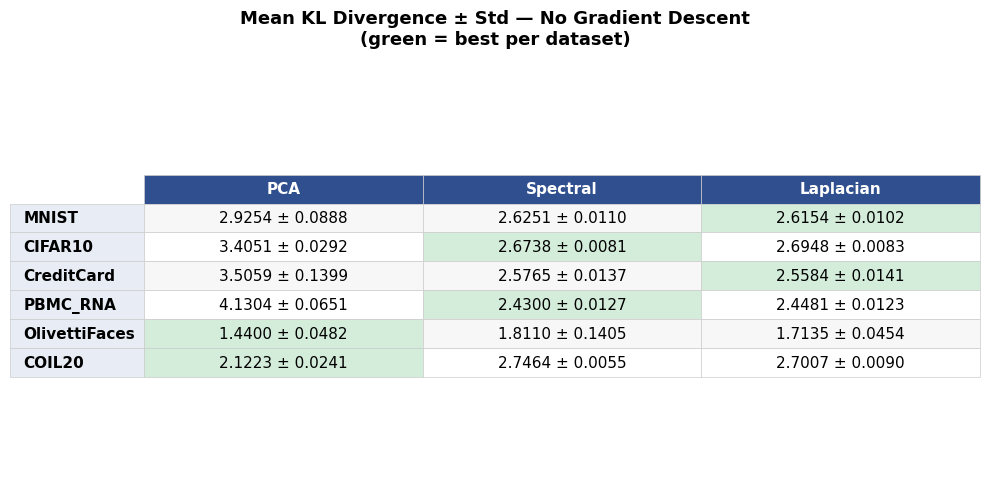

Saved: summary_table_init.png


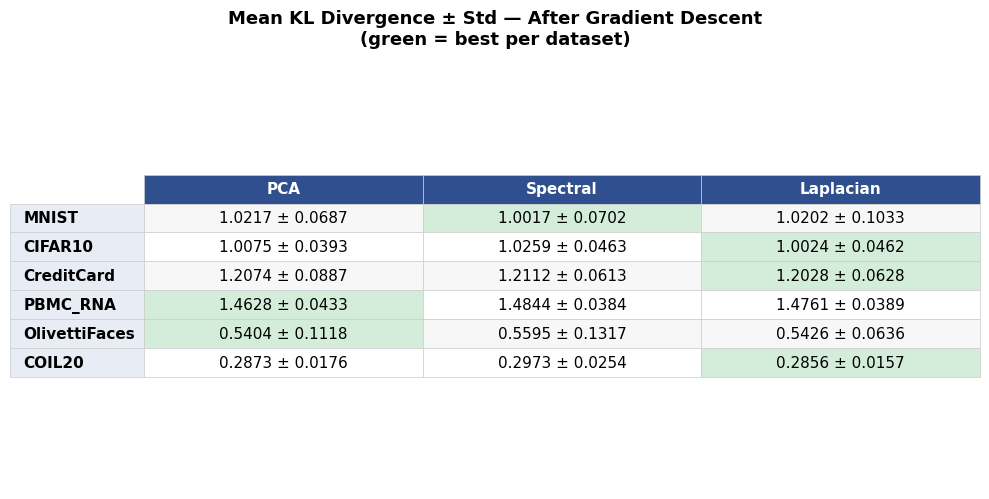

Saved: summary_table_gd.png


In [93]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_summary_table(all_results, mode="gd"):
    """
    Renders a clean thesis-ready table comparing KL divergence
    across datasets and initialization methods.
    mode: "gd" (after gradient descent) or "init" (no gradient descent)
    """
    key_kl = "gd_kl" if mode == "gd" else "init_kl"
    title_suffix = "After Gradient Descent" if mode == "gd" else "No Gradient Descent"
    methods = ["PCA", "Spectral", "Laplacian"]
    datasets = list(all_results.keys())

    # Build table data: mean ± std for each dataset × method
    cell_text = []
    for ds in datasets:
        row = []
        for m in methods:
            vals = all_results[ds][m][key_kl]
            row.append(f"{np.mean(vals):.4f} ± {np.std(vals):.4f}")
        cell_text.append(row)

    # Find best method per dataset (lowest mean KL) for highlighting
    best_col = []
    for ds in datasets:
        means = [np.mean(all_results[ds][m][key_kl]) for m in methods]
        best_col.append(np.argmin(means))

    # Color cells: highlight best in each row, subtle alternating row shading
    n_rows = len(datasets)
    n_cols = len(methods)
    cell_colors = []
    for i, ds in enumerate(datasets):
        row_colors = []
        base = "#F7F7F7" if i % 2 == 0 else "#FFFFFF"
        for j in range(n_cols):
            if j == best_col[i]:
                row_colors.append("#D4EDDA")  # soft green for best
            else:
                row_colors.append(base)
        cell_colors.append(row_colors)

    col_colors = ["#2F4F8F"] * n_cols
    row_colors_header = ["#2F4F8F"] * n_rows

    fig, ax = plt.subplots(figsize=(10, 0.55 * n_rows + 1.8))
    ax.axis("off")

    table = ax.table(
        cellText=cell_text,
        rowLabels=datasets,
        colLabels=methods,
        cellColours=cell_colors,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)

    # Style header row and row labels
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#CCCCCC")
        cell.set_linewidth(0.5)
        if row == 0:  # column headers
            cell.set_facecolor("#2F4F8F")
            cell.set_text_props(color="white", fontweight="bold", fontsize=11)
        if col == -1:  # row labels
            cell.set_facecolor("#E8EDF5")
            cell.set_text_props(fontweight="bold", fontsize=11)
            cell.set_width(0.22)

    # Title and legend
    fig.suptitle(
        f"Mean KL Divergence ± Std — {title_suffix}\n(green = best per dataset)",
        fontsize=13, fontweight="bold", y=0.97
    )

    plt.tight_layout()
    plt.savefig(f"summary_table_{mode}.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: summary_table_{mode}.png")


# Run both versions
plot_summary_table(all_results, mode="init")
plot_summary_table(all_results, mode="gd")